# Replicate 2 - Prototype Replication Deconvolution

In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [4]:
from pipeline.fit_replication_profiles import main

# Running from the parameter fits from a few months ago to compare
# the convergence speed and values from a cold start from the CLOCCS posteriors
parameter_updates_df, optimizer, replication_deconvolver = main(chrom=4, replicate=2,
    num_epochs=2, from_CLOCCS=True)


Loading initial cell cycle parameters from CLOCCS fits.
Shifting mu0, gamma1, and gamma2, for alpha...
Threshold windows with less than 75% read coverage.
Running initial iterations...
Initializing N using config H.
Initializing B using timepoint 0
Done.
Initial config parameters:              value    min   max
mu0     -0.151000 -30.00  30.0
delta   10.895300   0.00  24.0
sigma0  10.631000   1.00  14.0
sigmav   0.129700   0.01   1.0
lambda  60.209300  40.00  80.0
gamma1   0.333875   0.00   1.0
gamma2   0.615875   0.00   1.0
halted   0.290600   0.00   1.0
Running 2 epochs...
Epoch: 0
Optimization [1]: Current loss: 0.002843571356447086
Optimization [101]: Current loss: 0.002780945604744209
Optimization [201]: Current loss: 0.002778419451897391
Optimization [301]: Current loss: 0.00277827489809448
Optimization [401]: Current loss: 0.0027778412968730375
Optimization [501]: Current loss: 0.0027712521042095963
Optimization [601]: Current loss: 0.0027455499176861123
Optimization [701]: Curr

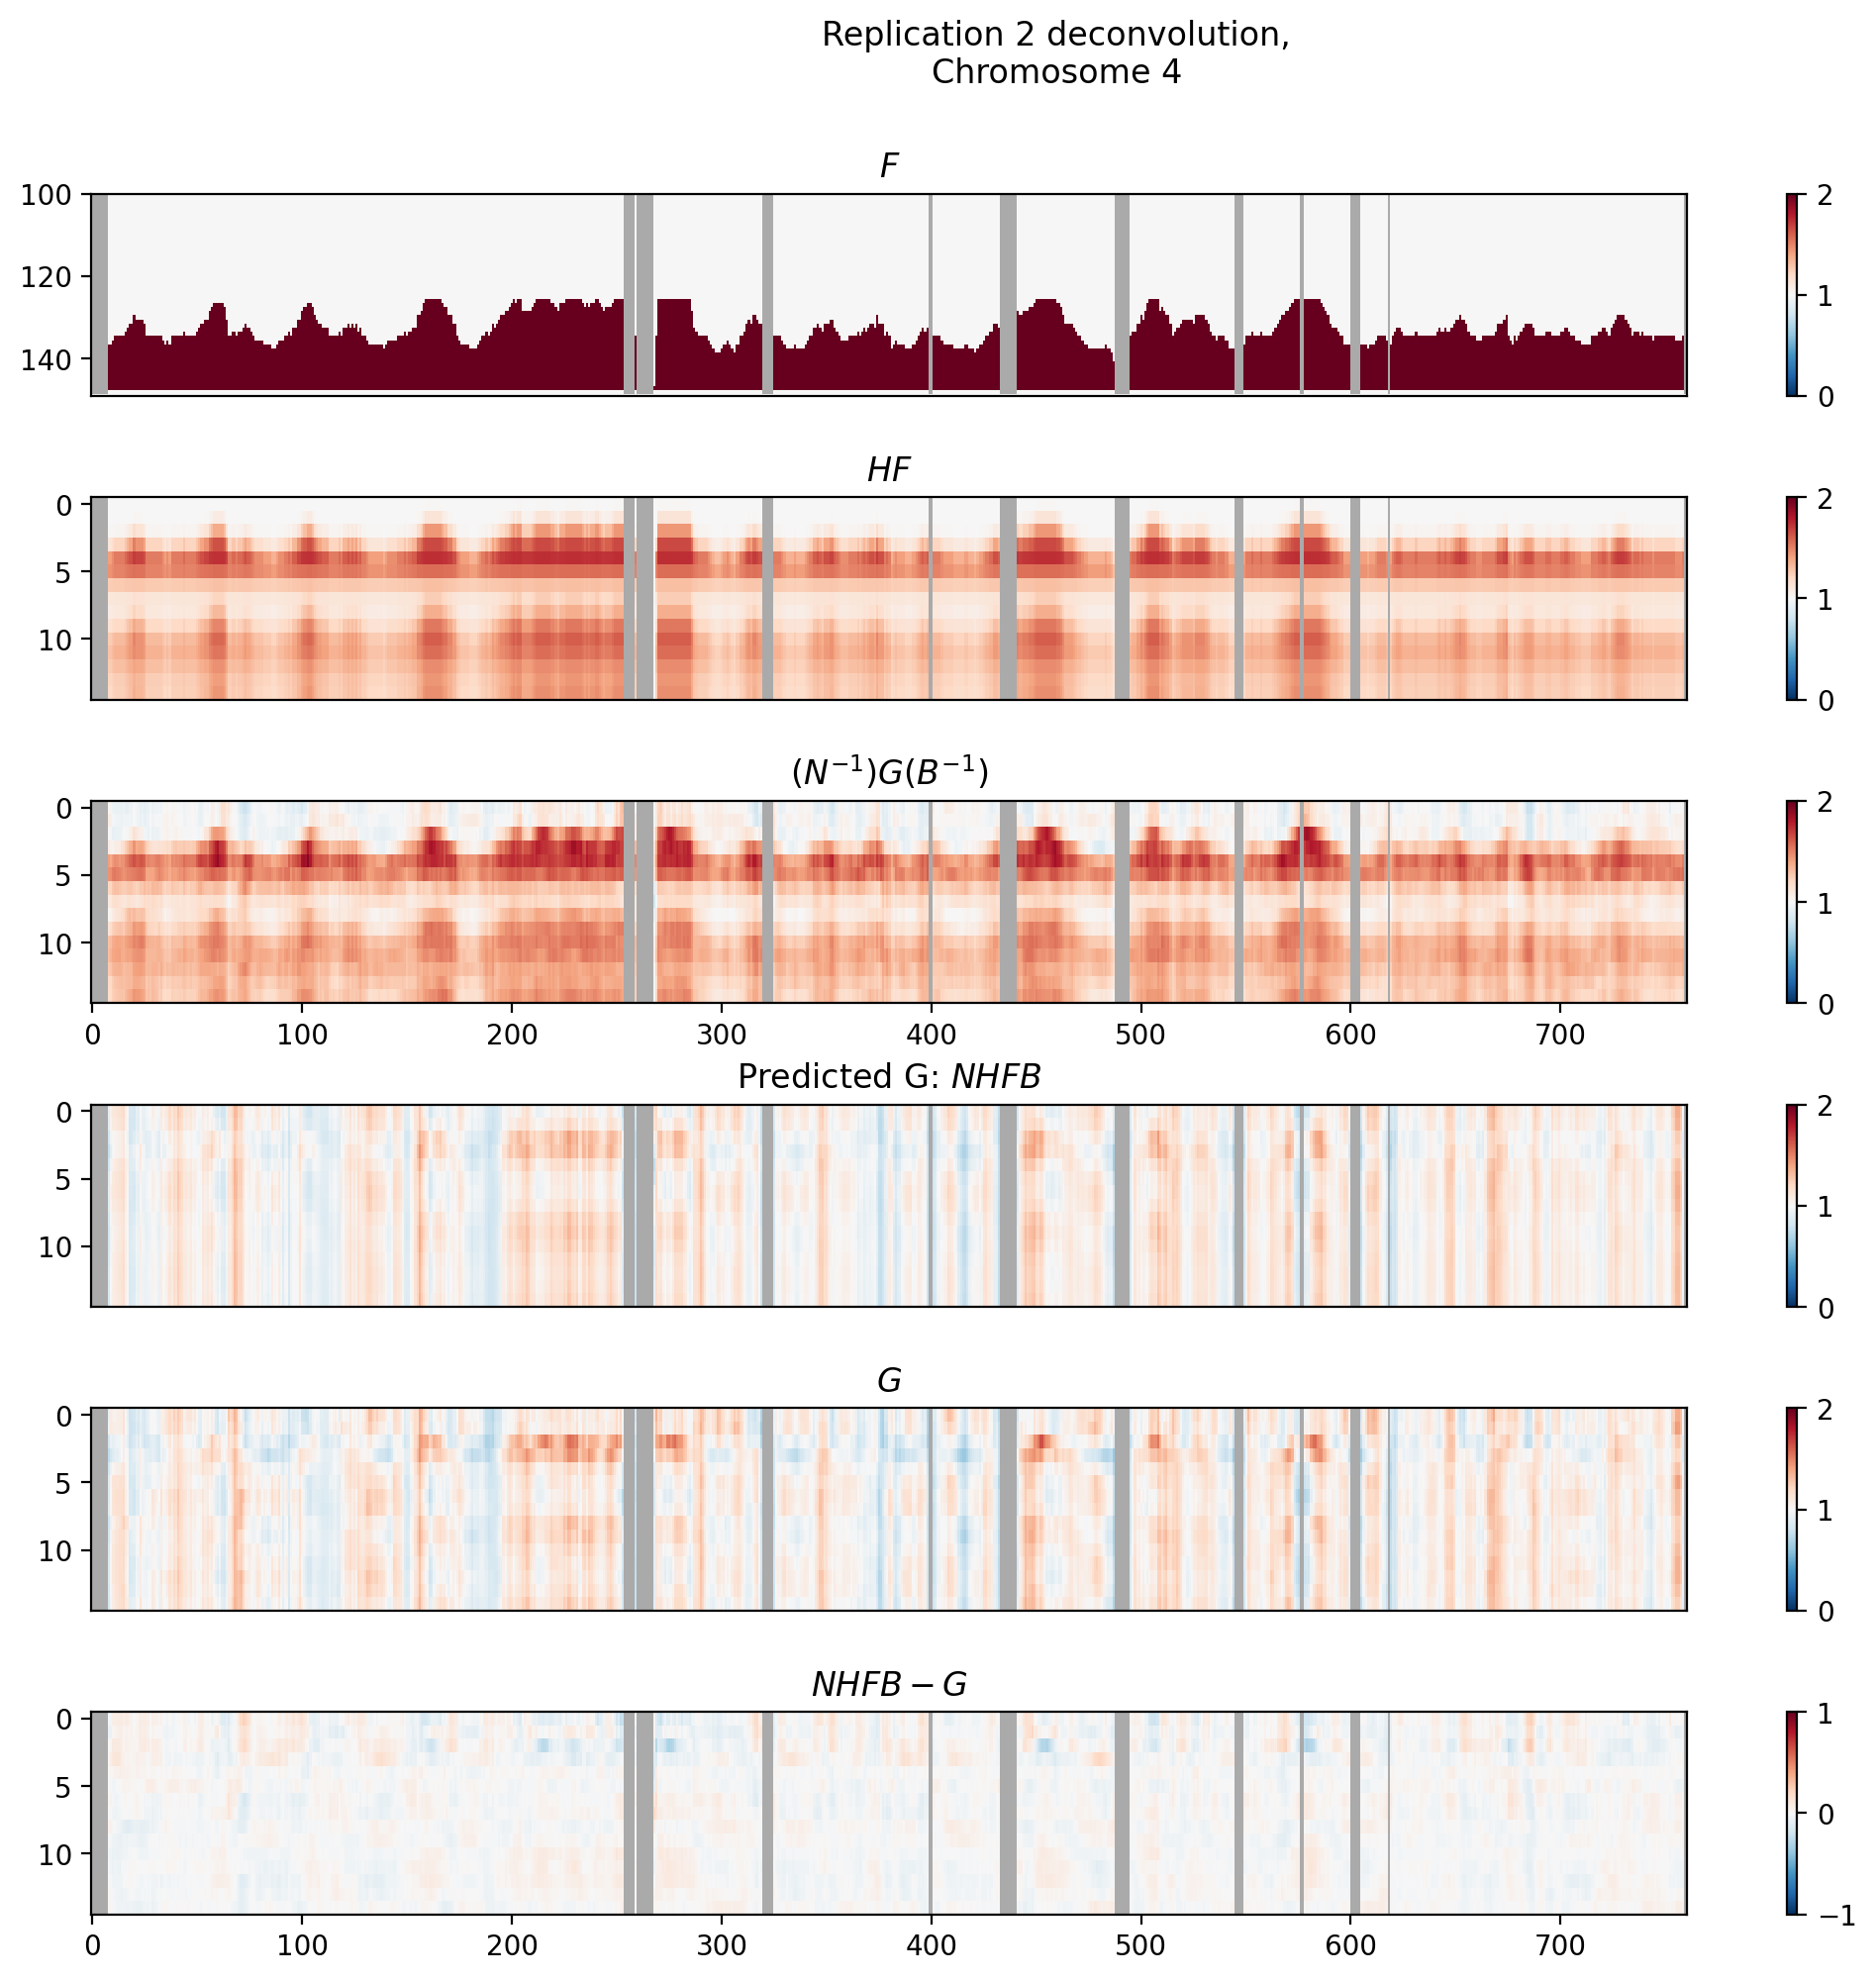

In [5]:
fig = replication_deconvolver.plot_heatmaps()

In [118]:
masked_G_df = replication_deconvolver.masked_G_df

# Select the indices in which the first three timepoints have a greater number
# of reads at any point than the average of the remaining.

timepoints = masked_G_df.index
alpha_tps = timepoints[:2]
remaining_tps = timepoints[2:]

max_occ_alpha_tps = masked_G_df.loc[alpha_tps].mean(axis=0)
avg_occ_remaining_tps = masked_G_df.loc[remaining_tps].mean(axis=0)

proportion_above = 0.2
mask_alpha = (avg_occ_remaining_tps * (1+proportion_above) < max_occ_alpha_tps)

There are 5/704 (0.7%)windows with >20.0% occupancy during alpha factor release compared to any other timepoint


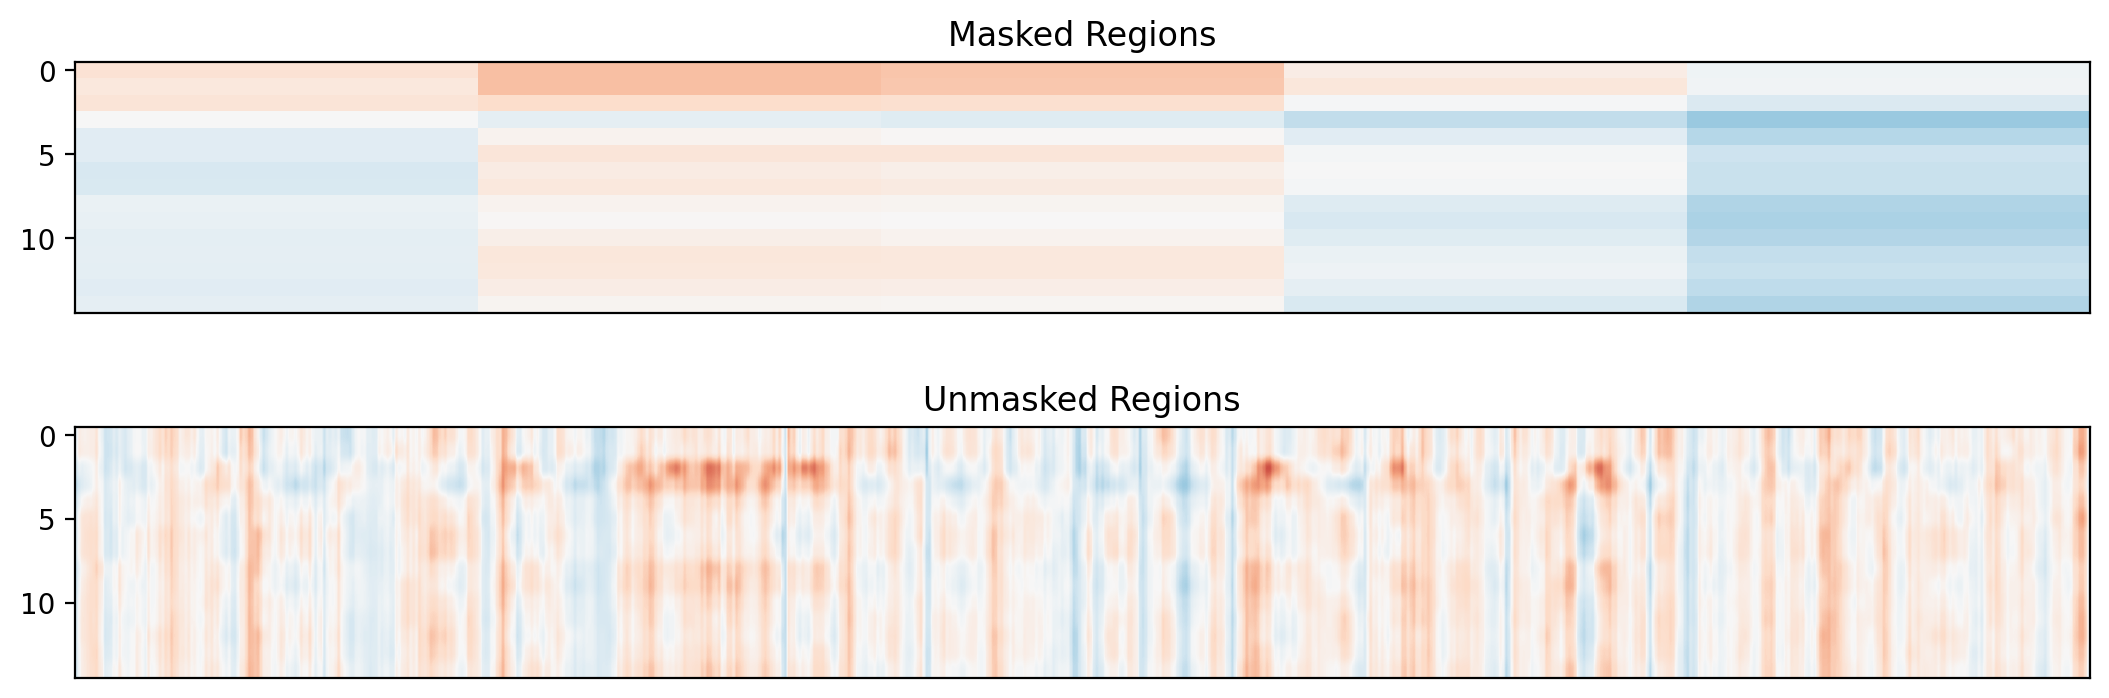

In [119]:
plt.figure(figsize=(13, 4))
plt.subplot(2, 1, 1)

masked_alpha_G_df = masked_G_df[masked_G_df.columns[mask_alpha]]

plt.imshow(masked_alpha_G_df,
          vmin=0, vmax=2, cmap='RdBu_r', aspect='auto')
plt.title("Masked Regions")
plt.xticks([])

plt.subplot(2, 1, 2)
plt.imshow(masked_G_df[masked_G_df.columns[~mask_alpha]],
          vmin=0, vmax=2, cmap='RdBu_r', aspect='auto')
plt.title("Unmasked Regions")
plt.xticks([])
plt.subplots_adjust(hspace=0.45)

num_masked = mask_alpha.sum()
num_total = masked_G_df.shape[1]

print(f"There are {num_masked}/{num_total} ({num_masked/num_total*100:.1f}%)"
      f"windows with >{proportion_above*100}% occupancy "
      f"during alpha factor release compared to any other timepoint")


In [122]:
from src.sgd import read_nondubious_genes_dataset

# Let's see if we have an enrichment for types of genes, expecting alpha-factor
# only chrIV, so it may not be enough n

genes = read_nondubious_genes_dataset()

chr4_genes = genes[genes.chr == 4]

selected_genes = []
for start_10k in masked_alpha_G_df.columns:
    end_10k = start_10k+10000
    mid = (start_10k+end_10k)/2
    search_span = mid-1000, mid+1000
    
    genes_in_10k = chr4_genes[(chr4_genes.TSS > search_span[0]) & 
                              (chr4_genes.TSS < search_span[1])]

    if len(genes_in_10k) > 0:
        selected_genes = selected_genes + list(genes_in_10k.index.values)

print(len(set(selected_genes)), len(chr4_genes))
genes.loc[selected_genes]

9 737


,gene,chr,cat,start,stop,strand,classification,length,TSS,PAS,manually_curated,promoter_start,promoter_end,gene_body_start,gene_body_end
orf_name,,,,,,,,,,,,,,,
YDR042C,YDR042C,4,gene,540601,541203,-,Uncharacterized,602,541279,540493.0,False,541279.0,541579.0,540779.0,541279.0
YDR077W,SED1,4,gene,600793,601809,+,Verified,1016,600751,602139.0,False,600451.0,600751.0,600751.0,601251.0
YDR078C,SHU2,4,gene,602198,602869,-,Verified,671,602887,602100.0,False,602887.0,603187.0,602387.0,602887.0
YDR079W,PET100,4,gene,603064,603399,+,Verified,335,603033,603520.0,False,602733.0,603033.0,603033.0,603533.0
YDR079C-A,TFB5,4,gene,603593,603811,-,Verified,218,603846,603382.0,False,603846.0,604146.0,603346.0,603846.0
YDR080W,VPS41,4,gene,604008,606986,+,Verified,2978,603972,607167.0,False,603672.0,603972.0,603972.0,604472.0
YDR259C,YAP6,4,gene,974631,975782,-,Verified,1151,976004,974495.0,False,976004.0,976304.0,975504.0,976004.0
YDR260C,SWM1,4,gene,976717,977229,-,Verified,512,977259,976378.0,False,977259.0,977559.0,976759.0,977259.0
YDR261C,EXG2,4,gene,977521,979209,-,Verified,1688,979263,977408.0,False,979263.0,979563.0,978763.0,979263.0
